# Online analysis for the IVU transverse impedance measurement

The goal of this notebook is to explore the data during the IVU transverse impedance machine study and progressively extract the quantities needed to estimate the transverse kick factor.

The analysis follows a simple path:

1. Load the data files.
2. Build bunch-to-bunch orbit differences:

\begin{equation}
\Delta u = u_{\rm high} - u_{\rm low},
\qquad u=x,y.
\end{equation}

3. Build current-normalized / charge-normalized orbit differences:

\begin{equation}
\Delta u_{\rm norm}
=
\frac{\Delta u}{\Delta q}.
\end{equation}

4. Check the consistency of the data across turns and acquisitions.
5. Study how $\Delta u$ and $\Delta u/\Delta q$ evolve with the bump $y_0$.
6. Fit the BPM-vector pattern to extract the IVU kick factor for each gap.

The final experimental quantity of interest is the transverse kick factor as a function of gap:

\begin{equation}
k_\perp(g).
\end{equation}

All numerical variables are stored in SI units unless explicitly stated otherwise. Plots may display values in $\mu\mathrm{m}$, $\mathrm{mm}$, or $\mathrm{nC}$ for readability.

## Imports

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mathphys.functions import load

parent_dir = os.path.dirname(os.getcwd())
ivu_orm_dir = os.path.join(parent_dir, "ivu_kick_respmat")
sys.path.append(ivu_orm_dir)

from ivu_orm import calc_ivu_orm

## Paths and Loading

Data description:

Each loaded file returns one dictionary `data_i` with the structure:
```
data_i = {
    "params": {...},
    "data": {...},
}
```

The `"params"` dictionary contains quantities imposed by the measurement configuration, for example:

- `gap` $\,$ [m]
- `y0` $\,$ [m]
- `n_acq` $\,$ []
- `n_turns` $\,$ []


The `"data"` dictionary contains measured quantities, directly at the next level, for example:

- `buc1_xpos` $\,$ *(n_bpms, n_acq, n_turns)* $\,$ [m]
- `buc2_xpos` 
- `buc1_ypos` $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\,$ $\,$ ...
- `buc2_ypos`
- `buc1_sum`
- `buc2_sum` $\;$ $\,$ *(n_bpms, n_acq, n_turns)* $\,$ [m]
- `sofb_orbit_x` $\,$ [m]
- `sofb_orbit_y` $\,$ [m]
- `corr_forces` $\,$ []
- `timestamp` $\,$ []
- `total_current` $\,$ [A]
- `buc1_current` $\,$ [A]
- `buc2_current` $\,$ [A]

Here, *n_bpms* = 160.

The sum and current signals may be scalars or arrays, depending on how the acquisition stores them. In the analysis, we use the mean bunch currents for each configuration.

The following quantities are added by the analysis notebook:

- `delta_current` $\,$ [A]
- `buc1_charge` $\,$ [C]
- `buc2_charge` $\,$ [C]
- `delta_charge` $\,$ [C]


### Paths

In [2]:
# Define possible data paths (measurement data and synthetic data)
# meas_data_dir = os.path.join(parent_dir, )  # Real data
synt_data_dir = os.path.join(parent_dir, 'tests_and_synthetic_data', 'data', 'synthetic')  # Synthetic data for preliminary tests

# Choose data source
data_dir = synt_data_dir 

In [3]:
file_names = [
    'synt_gap_4mm_dq_1p4nC_y0_1mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_0p5mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_0mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_-0p5mm.pickle',
    'synt_gap_4mm_dq_1p4nC_y0_-1mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_1mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_0p5mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_0mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_-0p5mm.pickle',
    'synt_gap_4mm_dq_2p6nC_y0_-1mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_1mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_0p5mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_0mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_-0p5mm.pickle',
    'synt_gap_14mm_dq_1p4nC_y0_-1mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_1mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_0p5mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_0mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_-0p5mm.pickle',
    'synt_gap_14mm_dq_2p6nC_y0_-1mm.pickle',
    'synt_gap_24mm_dq_1p4nC_y0_1mm.pickle',
    'synt_gap_24mm_dq_1p4nC_y0_0p5mm.pickle',
    'synt_gap_24mm_dq_1p4nC_y0_0mm.pickle',
    'synt_gap_24mm_dq_1p4nC_y0_-0p5mm.pickle',
    'synt_gap_24mm_dq_1p4nC_y0_-1mm.pickle',
    'synt_gap_24mm_dq_2p6nC_y0_1mm.pickle',
    'synt_gap_24mm_dq_2p6nC_y0_0p5mm.pickle',
    'synt_gap_24mm_dq_2p6nC_y0_0mm.pickle',
    'synt_gap_24mm_dq_2p6nC_y0_-0p5mm.pickle',
    'synt_gap_24mm_dq_2p6nC_y0_-1mm.pickle',
 ]

file_paths = [data_dir + '/' + file for file in file_names]

for file_path in file_paths:
    print(file_path)

/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_1mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_0p5mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_0mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_-0p5mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_1p4nC_y0_-1mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_2p6nC_y0_1mm.pickle
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/synthetic/synt_gap_4mm_dq_2p6nC_y0_0p5mm.pickle
/home/henrique.silvestre/fac-henr

### Loading (Synthetic Data)

Using synthetic data to get some intuition

In [4]:
data = []

for file_path in file_paths:
    data_i = load(file_path)
    data.append(data_i)

n_configs = len(data)  # []

print(f"Loaded {n_configs} configurations.")


Loaded 30 configurations.


### Add charges information

In [5]:
light_speed = 299_792_458.0  # [m/s]
circumference = 518.3898999999917  # [m]
rev_frequency = light_speed / circumference  # [Hz]

In [6]:
def get_mean_value(value):
    """Return the mean value as a scalar.

    Args:
        value (float or numpy.ndarray): Input value.

    Returns:
        mean_value (float): Mean value.

    """
    mean_value = float(np.mean(value))
    return mean_value

def add_charge_information(data):
    """Add charge information to the measured data.

    Args:
        data (list): List of measurement dictionaries.

    Returns:
        data (list): List of measurement dictionaries.

    """
    for data_i in data:
        data_meas = data_i["data"]

        buc1_current = get_mean_value(data_meas["buc1_current"])  # [A]
        buc2_current = get_mean_value(data_meas["buc2_current"])  # [A]

        delta_current = buc1_current - buc2_current  # [A]

        buc1_charge = buc1_current / rev_frequency  # [C]
        buc2_charge = buc2_current / rev_frequency  # [C]

        delta_charge = buc1_charge - buc2_charge  # [C]

        data_meas["delta_current"] = delta_current
        data_meas["buc1_charge"] = buc1_charge
        data_meas["buc2_charge"] = buc2_charge
        data_meas["delta_charge"] = delta_charge

    return data

In [7]:
data = add_charge_information(data)

## First data checks

In [8]:
data_check = data[0]

data_check_meas = data_check["data"]
data_check_params = data_check["params"]

print("\ndata[i] keys:")
print(data_check.keys())

print("\nparams keys:")
print(data_check_params.keys())

print("\ndata keys:")
print(data_check_meas.keys())

print("\nShapes:")
print("buc1_xpos:", np.shape(data_check_meas["buc1_xpos"]))
print("buc2_xpos:", np.shape(data_check_meas["buc2_xpos"]))
print("buc1_ypos:", np.shape(data_check_meas["buc1_ypos"]))
print("buc2_ypos:", np.shape(data_check_meas["buc2_ypos"]))
print("buc1_sum :", np.shape(data_check_meas["buc1_sum"]))
print("buc2_sum :", np.shape(data_check_meas["buc2_sum"]))

print("\nConfiguration:")
print(rf"gap     : {1e3*data_check_params['gap']:.2f} mm")
print(rf"y0      : {1e3*data_check_params['y0']:.2f} mm")
print(rf"n_acq   : {data_check_params['n_acq']}")
print(rf"n_turns : {data_check_params['n_turns']}")

print("\nCurrents and charges:")
print(rf"Bunch 1 current: {1e3*get_mean_value(data_check_meas['buc1_current']):.3f} mA")
print(rf"Bunch 2 current: {1e3*get_mean_value(data_check_meas['buc2_current']):.3f} mA")
print(rf"Delta current  : {1e3*data_check_meas['delta_current']:.3f} mA")
print(rf"Bunch 1 charge : {1e9*data_check_meas['buc1_charge']:.3f} nC")
print(rf"Bunch 2 charge : {1e9*data_check_meas['buc2_charge']:.3f} nC")
print(rf"Delta charge   : {1e9*data_check_meas['delta_charge']:.3f} nC")


data[i] keys:
dict_keys(['params', 'data'])

params keys:
dict_keys(['gap', 'y0', 'n_acq', 'n_turns', 'synthetic_truth'])

data keys:
dict_keys(['buc1_xpos', 'buc2_xpos', 'buc1_ypos', 'buc2_ypos', 'buc1_sum', 'buc2_sum', 'sofb_orbit_x', 'sofb_orbit_y', 'corr_forces', 'timestamp', 'total_current', 'buc1_current', 'buc2_current', 'delta_current', 'buc1_charge', 'buc2_charge', 'delta_charge'])

Shapes:
buc1_xpos: (160, 5, 100)
buc2_xpos: (160, 5, 100)
buc1_ypos: (160, 5, 100)
buc2_ypos: (160, 5, 100)
buc1_sum : (160, 5, 100)
buc2_sum : (160, 5, 100)

Configuration:
gap     : 4.00 mm
y0      : 1.00 mm
n_acq   : 5
n_turns : 100

Currents and charges:
Bunch 1 current: 0.925 mA
Bunch 2 current: 0.116 mA
Delta current  : 0.810 mA
Bunch 1 charge : 1.600 nC
Bunch 2 charge : 0.200 nC
Delta charge   : 1.400 nC


## Create a configuration table

In [9]:
def make_delta_q_group(delta_charge, step_nC=0.1):
    """Create integer charge group from measured charge difference.

    Args:
        delta_charge (float): Measured charge difference [C].
        step_nC (float): Charge grouping step [nC].

    Returns:
        delta_q_group (int): Integer charge group.

    """
    delta_q_nC = 1e9 * delta_charge  # [nC]
    delta_q_group = int(np.round(delta_q_nC / step_nC))  # []

    return delta_q_group


def make_config_table(data, delta_q_group_step_nC=0.1):
    """Create table with the main configuration parameters.

    Args:
        data (list): List of measurement dictionaries.
        delta_q_group_step_nC (float): Charge grouping step [nC].

    Returns:
        config_table (pandas.DataFrame): Table with one row per configuration.

    """
    rows = []

    for i, data_i in enumerate(data):
        data_meas = data_i["data"]
        params = data_i["params"]

        delta_charge = data_meas["delta_charge"]  # [C]

        delta_q_group = make_delta_q_group(
            delta_charge,
            step_nC=delta_q_group_step_nC,
        )  # []

        rows.append({
            "cfg": i,
            "gap": params["gap"],
            "y0": params["y0"],
            "n_acq": params["n_acq"],
            "n_turns": params["n_turns"],
            "delta_charge": delta_charge,
            "delta_q_group": delta_q_group,
            "delta_current": data_meas["delta_current"],
            "total_current": data_meas["total_current"],
            "buc1_current": get_mean_value(data_meas["buc1_current"]),
            "buc2_current": get_mean_value(data_meas["buc2_current"]),
        })

    config_table = pd.DataFrame(rows)

    return config_table

In [10]:
delta_q_group_step_nC = 0.1  # [nC]

config_table = make_config_table(
    data,
    delta_q_group_step_nC=delta_q_group_step_nC,
)

config_table

,cfg,gap,y0,n_acq,n_turns,delta_charge,delta_q_group,delta_current,total_current,buc1_current,buc2_current
0,0,0.004,0.0010,5,100,1.400000e-09,14,0.000810,0.001041,0.000925,0.000116
1,1,0.004,0.0005,5,100,1.400000e-09,14,0.000810,0.001041,0.000925,0.000116
2,2,0.004,0.0000,5,100,1.400000e-09,14,0.000810,0.001041,0.000925,0.000116
3,3,0.004,-0.0005,5,100,1.400000e-09,14,0.000810,0.001041,0.000925,0.000116
4,4,0.004,-0.0010,5,100,1.400000e-09,14,0.000810,0.001041,0.000925,0.000116
5,5,0.004,0.0010,5,100,2.600000e-09,26,0.001504,0.001735,0.001619,0.000116
6,6,0.004,0.0005,5,100,2.600000e-09,26,0.001504,0.001735,0.001619,0.000116
7,7,0.004,0.0000,5,100,2.600000e-09,26,0.001504,0.001735,0.001619,0.000116
8,8,0.004,-0.0005,5,100,2.600000e-09,26,0.001504,0.001735,0.001619,0.000116
9,9,0.004,-0.0010,5,100,2.600000e-09,26,0.001504,0.001735,0.001619,0.000116


Or for better readability:

In [11]:
config_table_view = config_table.copy()

config_table_view["gap_mm"] = 1e3 * config_table_view["gap"]
config_table_view["y0_mm"] = 1e3 * config_table_view["y0"]

config_table_view["delta_q_nC"] = 1e9 * config_table_view["delta_charge"]

config_table_view["buc1_current_mA"] = (1e3 * config_table_view["buc1_current"]).round(3)
config_table_view["buc2_current_mA"] = (1e3 * config_table_view["buc2_current"]).round(3)
config_table_view["total_current_mA"] = (1e3 * config_table_view["total_current"]).round(3)
config_table_view["delta_current_mA"] = (1e3 * config_table_view["delta_current"]).round(3)

config_table_view = config_table_view[[
    "cfg",
    "gap_mm",
    "y0_mm",
    "delta_q_nC",
    "delta_q_group",
    "buc1_current_mA",
    "buc2_current_mA",
    "total_current_mA",
    "delta_current_mA",
]]

config_table_view

,cfg,gap_mm,y0_mm,delta_q_nC,delta_q_group,buc1_current_mA,buc2_current_mA,total_current_mA,delta_current_mA
0,0,4.0,1.0,1.4,14,0.925,0.116,1.041,0.810
1,1,4.0,0.5,1.4,14,0.925,0.116,1.041,0.810
2,2,4.0,0.0,1.4,14,0.925,0.116,1.041,0.810
3,3,4.0,-0.5,1.4,14,0.925,0.116,1.041,0.810
4,4,4.0,-1.0,1.4,14,0.925,0.116,1.041,0.810
5,5,4.0,1.0,2.6,26,1.619,0.116,1.735,1.504
6,6,4.0,0.5,2.6,26,1.619,0.116,1.735,1.504
7,7,4.0,0.0,2.6,26,1.619,0.116,1.735,1.504
8,8,4.0,-0.5,2.6,26,1.619,0.116,1.735,1.504
9,9,4.0,-1.0,2.6,26,1.619,0.116,1.735,1.504


## Build orbit-difference arrays

For each configuration, the bunch $x$ and $y$ signals (${x_1}$, ${x_2}$, ${x_{sum}}$, ${y_1}$, ${y_2}$, ${y_{sum}}$) have shape:

\begin{equation}
(160,\ n_{\rm acq},\ n_{\rm turns}).
\end{equation}

After stacking all configurations, the corresponding orbit arrays have shape:

\begin{equation}
(n_{\rm configs},\ 160,\ n_{\rm acq},\ n_{\rm turns}).
\end{equation}

We then define:

\begin{equation}
\Delta x = x_1 - x_2,
\qquad
\Delta y = y_1 - y_2.
\end{equation}

We also define the charge-normalized quantities:

\begin{equation}
\Delta x_{\rm norm} = \frac{\Delta x}{\Delta q},
\qquad
\Delta y_{\rm norm} = \frac{\Delta y}{\Delta q}.
\end{equation}

To generalize for both planes, we can call these orbit differences $\Delta u$ and $\Delta u_{\rm norm}$, which will be the names used throught this notebook.

In [12]:
def stack_orbit_data(data, plane="y"):
    """Stack bunch orbit data for one plane.

    Args:
        data (list): List of measurement dictionaries.
        plane (str, optional): Transverse plane. Use 'x' or 'y'.

    Returns:
        buc1_pos (numpy.ndarray): Bunch 1 position array [m].
        buc2_pos (numpy.ndarray): Bunch 2 position array [m].
        delta_pos (numpy.ndarray): Bunch-to-bunch difference [m].

    """
    if plane == "x":
        key1 = "buc1_xpos"
        key2 = "buc2_xpos"
    elif plane == "y":
        key1 = "buc1_ypos"
        key2 = "buc2_ypos"
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    buc1_pos = np.array([data_i["data"][key1] for data_i in data])  # [m]
    buc2_pos = np.array([data_i["data"][key2] for data_i in data])  # [m]

    delta_pos = buc1_pos - buc2_pos  # [m]

    return buc1_pos, buc2_pos, delta_pos


def normalize_by_charge(delta_pos, config_table):
    """Normalize orbit difference by bunch charge difference.

    Args:
        delta_pos (numpy.ndarray): Bunch-to-bunch orbit difference [m].
        config_table (pandas.DataFrame): Configuration table.

    Returns:
        delta_pos_norm (numpy.ndarray): Charge-normalized orbit difference [m/C].

    """
    delta_q = config_table["delta_charge"].to_numpy()  # [C]
    delta_pos_norm = delta_pos / delta_q[:, None, None, None]  # [m/C]
    
    return delta_pos_norm

In [13]:
delta_q = config_table["delta_charge"].to_numpy()
print(delta_q[:, None, None, None].shape)

(30, 1, 1, 1)


 Get full Delta u arrays

In [14]:
buc1_ypos, buc2_ypos, delta_ypos = stack_orbit_data(data, plane="y")
buc1_xpos, buc2_xpos, delta_xpos = stack_orbit_data(data, plane="x")

delta_ypos_norm = normalize_by_charge(delta_ypos, config_table)
delta_xpos_norm = normalize_by_charge(delta_xpos, config_table)

print("delta_ypos shape      :", delta_ypos.shape)
print("delta_ypos_norm shape :", delta_ypos_norm.shape)
print("delta_xpos shape      :", delta_xpos.shape)
print("delta_xpos_norm shape :", delta_xpos_norm.shape)

delta_ypos shape      : (30, 160, 5, 100)
delta_ypos_norm shape : (30, 160, 5, 100)
delta_xpos shape      : (30, 160, 5, 100)
delta_xpos_norm shape : (30, 160, 5, 100)


## First plots

### Helpers

In [15]:
def get_delta_u(plane="y", normalized=False):
    """Get orbit-difference array for one plane (Delta u).

    Args:
        plane (str): Transverse plane. use 'x' or 'y'.
        normalized (bool): Whether Delta u is charge-normalized.
            
    Returns:
        delta_u (numpy.ndarray): Orbit-difference array. 
            Shape (n_configs, n_bpms, n_acq, n_turns).

    """
    if plane == "x":
        delta_u = delta_xpos_norm if normalized else delta_xpos
    elif plane == "y":
        delta_u = delta_ypos_norm if normalized else delta_ypos
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    return delta_u


def get_plot_scale(plane="y", normalized=False):
    """Get scale and label for plotting.

    Args:
        plane (str): Transverse plane. use 'x' or 'y'.
        normalized (bool): Whether Delta u is charge-normalized.

    Returns:
        scale (float): Multiplicative scale.
        ylabel (str): Axis label.

    """
    if normalized:
        scale = 1e-3
        ylabel = rf"$\Delta {plane} / \Delta q$ [$\mu$m/nC]"
    else:
        scale = 1e6
        ylabel = rf"$\Delta {plane}$ [$\mu$m]"

    return scale, ylabel

### One configuration, acquisition and turn

Considering the full position displacement vector for the plane $u$, $\mathbf{\Delta u}$, we can write the element corresponding to configuration $c$, BPM $i$, acquisition $j$, and turn $k$, as:

\begin{equation}
\Delta u(c,i,j,k),
\end{equation}

Then, to begin, let's select one configuration, acquisition and turn (i.e., fixed $c$, $j$, and $k$), and plot the full $\Delta u_{c,j,k} (i)$ profile across the ring. 

First, we can quickly get ``spos_bpms`` using the _calc_ivu_orm_ function, which will be handful for the plots.

In [16]:
_, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)
spos_bpms = orm_info["spos_bpms"]  # [m]

In [17]:
def plot_single_profile(cfg=0, acq=0, turn=0, plane="y", normalized=False):
    """Plot Delta u profile across BPMs for one configuration, acquisition and turn.

    Args:
        cfg (int): Configuration index.
        acq (int): Acquisition index.
        turn (int): Turn index.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    profile = delta_u[cfg, :, acq, turn]

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(spos_bpms, scale * profile, ".-")

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ profile, cfg={cfg}, acq={acq}, turn={turn} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

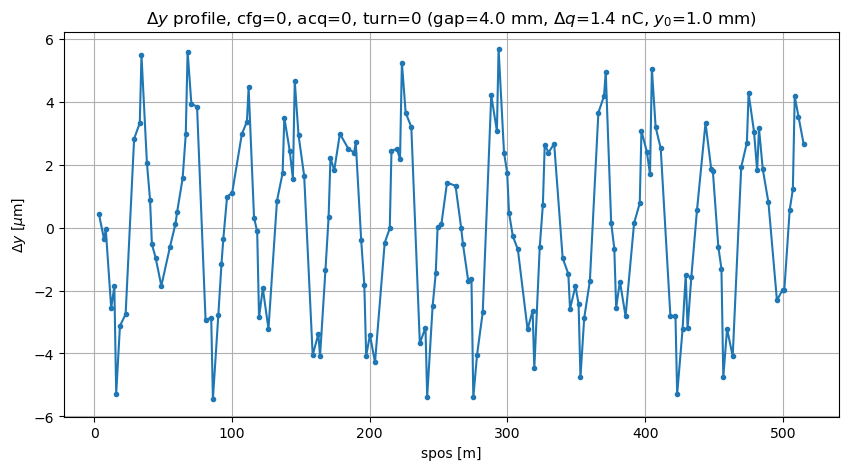

In [18]:
plot_single_profile(cfg=0, acq=0, turn=0, plane="y", normalized=False)

### One Configuration and one aquisition

Now, let's overlay orbits from multiple turns from one acquisition $-$ meaning: plot $\Delta u_{c,i,k} (j)$ for some selected $k's$.

*It can help us see if the turn-to-turn fluctuations are small, or if the full BPM profile changes significantly inside one acquisition.*

In [19]:
def plot_turns_in_acquisition(cfg=0, acq=0, turns=[0], plane="y", normalized=False, legend=False):
    """Plot Delta u profiles across BPMs for selected turns inside one acquisition.

    Args:
        cfg (int): Configuration index.
        acq (int): Acquisition index.
        turns (list): Turn indices.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.
        legend(bool): Whether to include legend.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(normalized=normalized)

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))

    for turn in turns:
        profile = delta_u[cfg, :, acq, turn]
        ax.plot(spos_bpms, scale * profile, ".-", alpha=0.4, label=rf'turn {turn}')

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ per turn, cfg={cfg}, acq={acq} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if legend: ax.legend()
    plt.show()

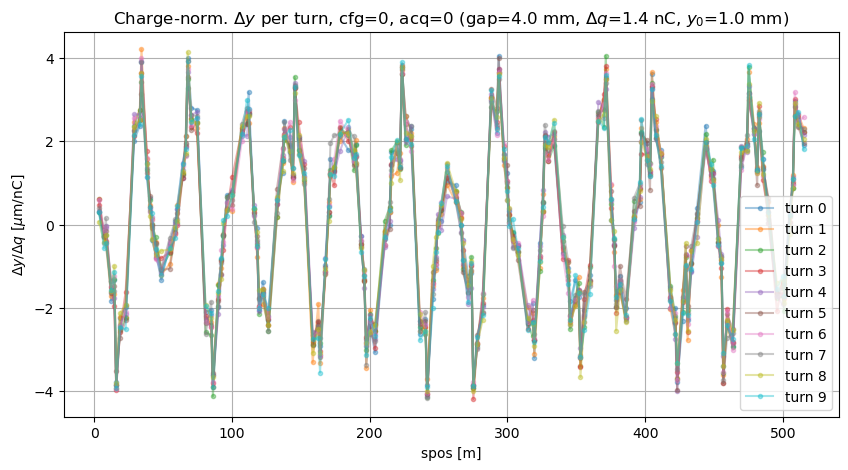

In [20]:
plot_turns_in_acquisition(cfg=0, acq=0, turns=range(0,10), plane="y", normalized=True, legend=True)

We can also see the turn-distribution for a single BPM.

(i.e., plot $\Delta u_{c,i,j}(k)$)

In [21]:
def plot_one_bpm_for_acquisitions(cfg=0, acqs=[0], bpm=0, plane="y", normalized=False):
    """Plot, for one BPM, the Delta u profile across turns for several acquisitions.

    Args:
        cfg (int): Configuration index.
        acqs (list): Acquisition indices.
        bpm (int): BPM index.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge-normalized.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane, normalized=normalized)

    row = config_table.iloc[cfg]

    fig, ax = plt.subplots(figsize=(10, 5))

    turns = range(delta_u.shape[3])

    for acq in acqs:
        bpm_profile = delta_u[cfg, bpm, acq, :]  # [m] or [m/C]

        ax.plot(
            turns,
            scale * bpm_profile,
            ".-",
            alpha=0.6,
            label=f"acq {acq}",
        )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ BPM {bpm}, cfg={cfg} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("turn idx []")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

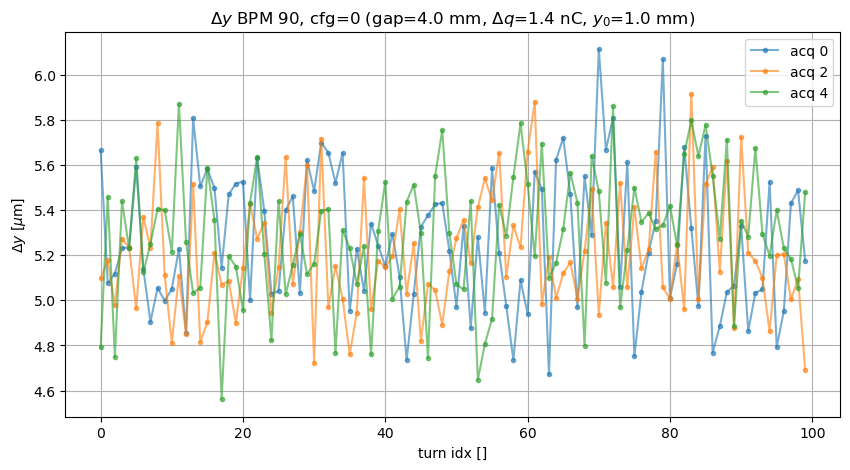

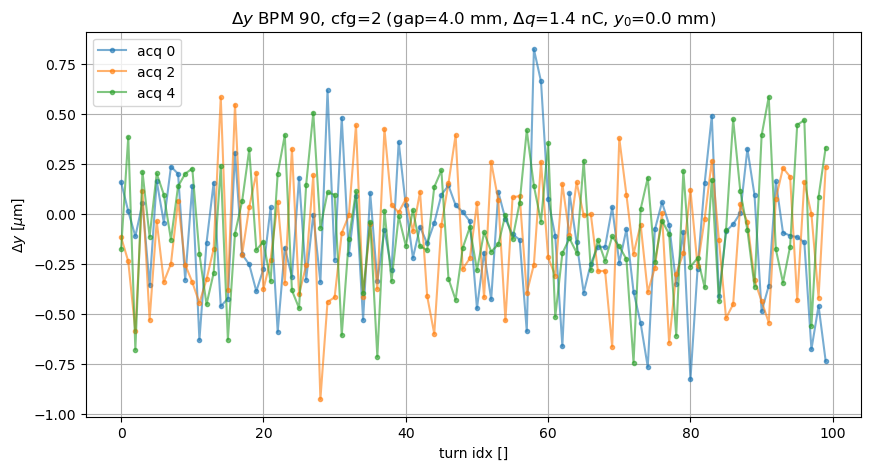

In [22]:
plot_one_bpm_for_acquisitions(cfg=0, acqs=[0, 2, 4], bpm=90, normalized=False)
plot_one_bpm_for_acquisitions(cfg=2, acqs=[0, 2, 4], bpm=90, normalized=False)

### Mean profile per acquisition

For each acquisition, we can average over turns (index $k$):

\begin{equation}
\langle \Delta u \rangle_{\rm turns}(c,i,j)
=
\langle \Delta u \rangle_{\rm k}(c,i,j)
=
\frac{1}{n_{\rm turns}}
\sum_k
\Delta u(c,i,j,k).
\end{equation}

And also calculate the corresponding $std$:

\begin{equation}
\mathrm{std}_{k}
\left[
\Delta u(c,i,j,k)
\right],
\end{equation}

which can give a first estimate of the stability inside each acquisition.

In [23]:
def plot_acquisition_means(cfg=0, acqs='all', plane="y", normalized=False, stds=False, legend=False):
    """Plot mean Delta u profile with stds for specified acquisitions of one configuration.

    Args:
        cfg (int): Configuration index.
        acqs (list): Aquisitions to plot. Defaults to 'all', plotting all 
            available ones.
        plane (str): Transverse plane.
        normalized (bool, optional): Whether Delta u is charge-normalized.
        legend (bool): Whether to include legend.

    """
    delta_u = get_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(plane=plane,normalized=normalized)

    delta_u_cfg = delta_u[cfg]  # [m] or [m/C]
    mean_by_acq = np.mean(delta_u_cfg, axis=2)  # [n_bpms, n_acq]
    std_by_acq = np.std(delta_u_cfg, axis=2)  # [n_bpms, n_acq]

    row = config_table.iloc[cfg]

    if acqs == 'all':
            acqs = range(mean_by_acq.shape[1])

    fig, ax = plt.subplots(figsize=(10, 5))

    for acq in acqs:
        if stds:
            ax.errorbar(
                spos_bpms,
                scale * mean_by_acq[:, acq],
                yerr=scale * std_by_acq[:, acq],
                marker=".",
                capsize=3,
                label=rf'acq {acq}'
            )
        else:
             ax.plot(
                spos_bpms,
                scale * mean_by_acq[:, acq],
                '.-',
                alpha=0.4,
                label=rf'acq {acq}'
             )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\langle\Delta {plane}\rangle$ profile per acquisition, cfg={cfg} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    if legend: ax.legend()
    plt.show()


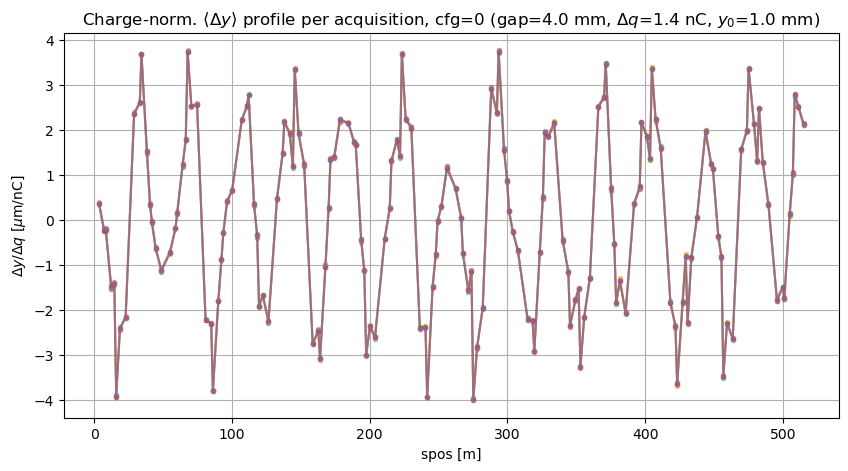

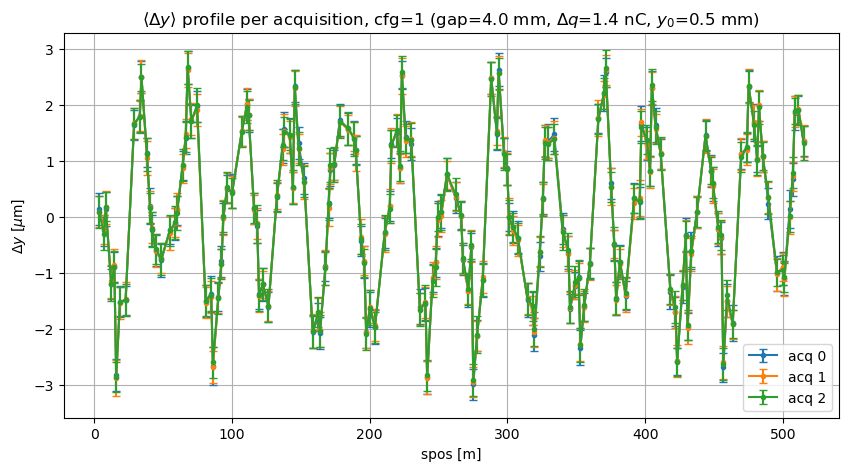

In [24]:
plot_acquisition_means(cfg=0, plane="y", normalized=True)
plot_acquisition_means(cfg=1, plane="y", acqs=range(0,3), normalized=False, stds=True, legend=True)


### Mean profile for one configuration

Now, for each configuration, we can average over all acquisitions and turns:

\begin{equation}
\overline{\Delta u}(c,i)
=
\left\langle \Delta u \right\rangle_{j,k}(c,i) = 
\frac{1}{n_{\rm acq}n_{\rm turns}} \sum_{j,k} \Delta u(c,i,j,k).
\end{equation}

_(reminder: $c$ refers to config. index, $i$ to BPM index, $j$ to acquisition index, and $k$ to turn index)_

And we also calculate the standard deviation:

\begin{equation}
\sigma_{\Delta u}(c,i)
=
\mathrm{std}_{j,k}
\left[
\Delta u(c,i,j,k)
\right].
\end{equation}

**Resulting in arrays $\overline{\Delta u}$ and $\sigma_{\Delta u}$ of dimensions** (*n_configs, n_bpms*) **, which will be central for the subsequent analyses.**

In [25]:
def process_delta_u(delta_u):
    """Calculate mean, std and standard error of Delta u for each
        configuration.

    Args:
        delta_u (numpy.ndarray): Orbit-difference array with shape
            (n_configs, n_bpms, n_acq, n_turns).

    Returns:
        delta_u_proc (dict): Dictionary with mean, std and sem arrays.
        Arrays dimension: (n_configs, n_bpms).

    """
    mean = np.mean(delta_u, axis=(2, 3))  # []
    std = np.std(delta_u, axis=(2, 3))  # []

    n_samples = delta_u.shape[2] * delta_u.shape[3]  # []
    sem = std / np.sqrt(n_samples)  # []

    delta_u_proc = {
        "mean": mean,
        "std": std,
        "sem": sem,
    }

    return delta_u_proc

In [26]:
delta_y_proc = process_delta_u(delta_ypos)
delta_y_proc_norm = process_delta_u(delta_ypos_norm)

delta_x_proc = process_delta_u(delta_xpos)
delta_x_proc_norm = process_delta_u(delta_xpos_norm)

In [27]:
print(delta_y_proc['mean'].shape)

(30, 160)


Plot one (or some) processed configuration(s):

In [28]:
def get_processed_delta_u(plane="y", normalized=False):
    """Get chosen processed Delta u data.

    Args:
        plane (str): Transverse plane.
        normalized (bool): Whether to use charge-normalized Delta u.

    Returns:
        processed (dict): Processed data dictionary.

    """
    if plane == "y":
        delta_u_proc = delta_y_proc_norm if normalized else delta_y_proc
    elif plane == "x":
        delta_u_proc = delta_x_proc_norm if normalized else delta_x_proc
    else:
        raise ValueError("plane must be 'x' or 'y'.")

    return delta_u_proc

def plot_config_mean(cfgs=[0], plane="y", normalized=False, use_sem=False):
    """Plot mean profile and error bars for one configuration.

    Args:
        cfgs (list): Configuration indexes.
        plane (str): Transverse plane.
        normalized (bool): Whether Delta u is charge normalized.
        use_sem (bool): Use standard error instead of std.

    """
    delta_u_proc = get_processed_delta_u(plane=plane, normalized=normalized)

    scale, ylabel = get_plot_scale(normalized=normalized)

    fig, ax = plt.subplots(figsize=(10, 5))

    for cfg in cfgs:
        mean = delta_u_proc["mean"][cfg]  # []
        err_key = "sem" if use_sem else "std"
        err = delta_u_proc[err_key][cfg]  # []

        row = config_table.iloc[cfg]

        ax.errorbar(
            spos_bpms,
            scale * mean,
            yerr= scale * err,
            marker=".",
            capsize=3,
            alpha=0.7,
            label=rf"$gap$={1e3*row['gap']:.1f} mm | $\Delta q$={1e9*row['delta_charge']:.1f} nC | $y_0$={1e3*row['y0']:.1f} mm"
        )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\langle\Delta {plane}$"
        r"$\rangle_{acqs,turns}$ profile"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

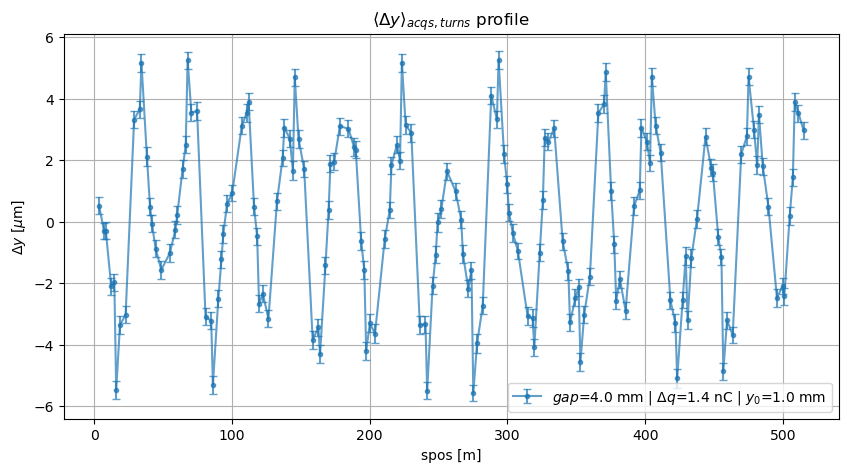

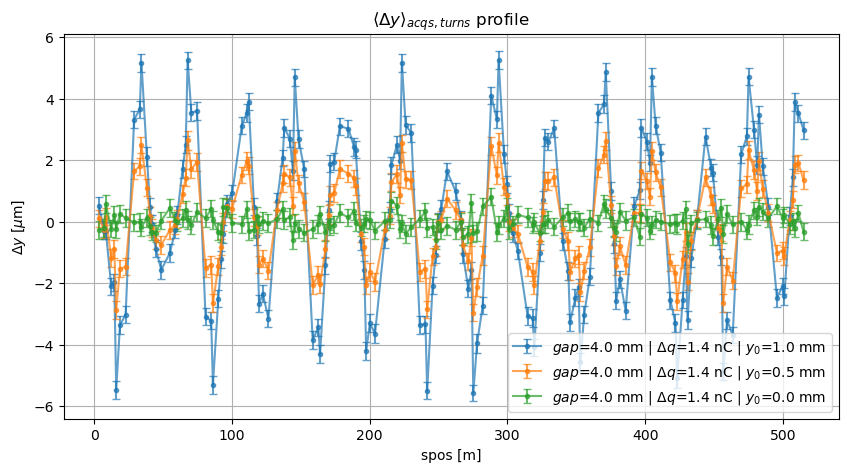

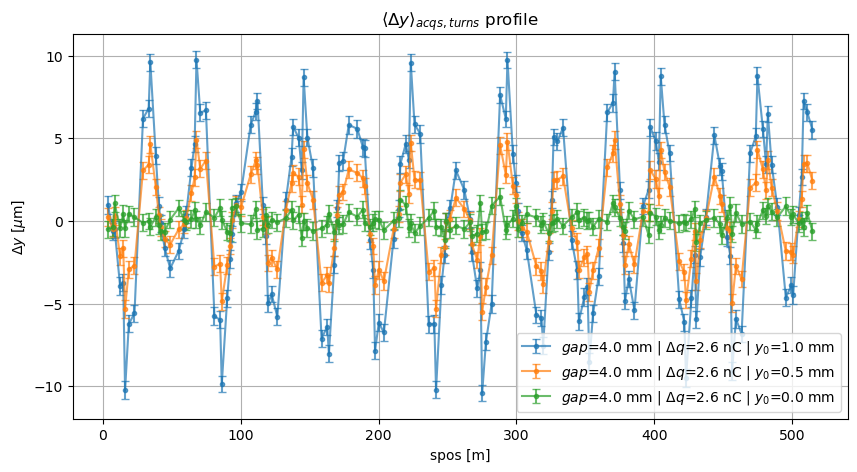

In [29]:
plot_config_mean(cfgs=[0], plane="y", normalized=False)
plot_config_mean(cfgs=range(0,3), plane="y", normalized=False)
plot_config_mean(cfgs=range(5,8), plane="y", normalized=False)

### Single BPM view: $\overline{\Delta u}_i$ versus $y_0$

Before doing a fit for each configuration using all BPMs, it is useful to look at individual BPMs to see if $\overline{\Delta u}_i(\Delta q, y_0)$ follows the expected behavior.

For one BPM and one gap, we can plot:

\begin{equation}
    \overline{\Delta u_i}
\quad \text{vs} \quad y_0
\end{equation}

for different values of $\Delta q$. 

**We expect $\overline{\Delta u_i}$ to grow approx. linearly with both $\Delta q$ and $y_0$.**

Then, we'll plot:

\begin{equation}
\frac{\Delta u_i}{\Delta q}
\quad \text{vs} \quad y_0.
\end{equation}

And if the signal follows the expected charge dependence, curves with different $\Delta q$ should approximately collapse in the normalized plot!

In [30]:
def plot_delta_u_bpm_vs_y0(bpm=0, gap=None, plane="y", normalized=False):
    """Plot one BPM value as a function of y0.

    Args:
        bpm (int): BPM index.
        gap (float): IVU gap [m].
        plane (str): Transverse plane.
        normalized (bool): Whether to plot charge-normalized data.

    """
    if gap is None:
        gap = config_table["gap"].unique()[0]

    delta_u_proc = get_processed_delta_u(plane=plane, normalized=normalized)
    scale, ylabel = get_plot_scale(normalized=normalized)

    mean = delta_u_proc["mean"][:, bpm]  # []
    std = delta_u_proc["std"][:, bpm]  # []

    fig, ax = plt.subplots(figsize=(8, 5))

    delta_q_group = config_table["delta_q_group"].to_numpy()  # []
    groups = np.sort(np.unique(delta_q_group))

    for group in groups:
        mask = (
            np.isclose(config_table["gap"], gap, rtol=0, atol=1e-12)
            & (config_table["delta_q_group"] == group)
        )

        idx = config_table.index[mask].to_numpy()

        if len(idx) == 0:
            continue

        y0_vals = config_table.loc[idx, "y0"].to_numpy()  # [m]
        order = np.argsort(y0_vals)

        idx = idx[order]
        y0_vals = y0_vals[order]

        group_nC = group * delta_q_group_step_nC  # [nC]

        ax.errorbar(
            1e3 * y0_vals,
            scale * mean[idx],
            yerr=scale * std[idx],
            marker="o",
            capsize=3,
            linestyle="-",
            label=rf"$\Delta q_{{\rm group}}$ = {group_nC:.1f} nC",
        )

    ax.set_title(
        rf"{normalized*'Charge-norm. '}"
        rf"$\Delta {plane}$ vs $y_0$, BPM {bpm}, "
        rf"gap = {1e3*gap:.1f} mm"
    )
    ax.set_xlabel(r"$y_0$ [mm]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

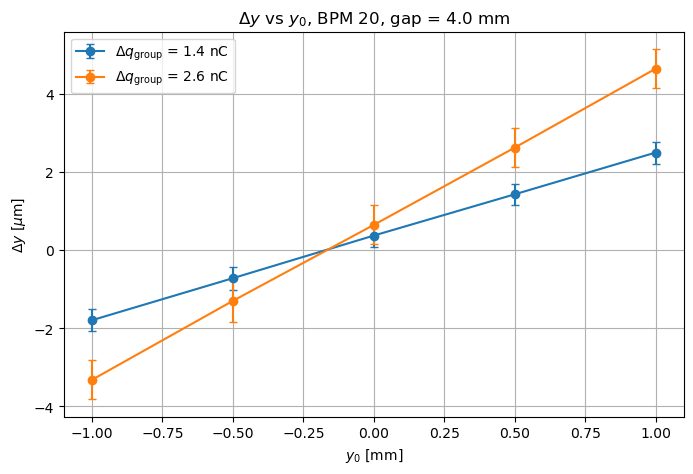

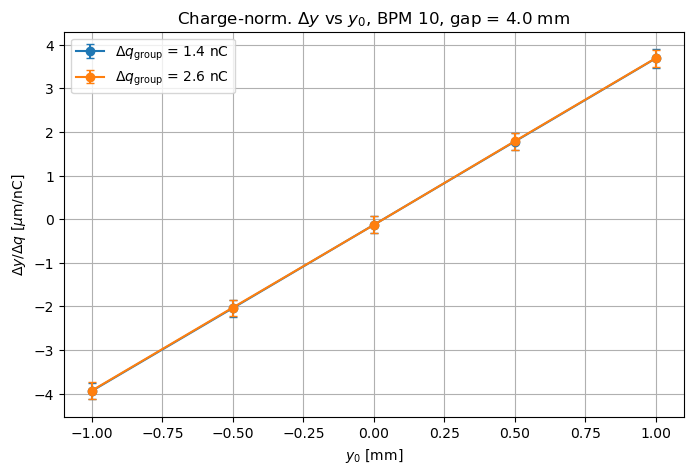

In [31]:
plot_delta_u_bpm_vs_y0(bpm=20, gap=4.0e-3, plane="y", normalized=False)
plot_delta_u_bpm_vs_y0(bpm=10, gap=4.0e-3, plane="y", normalized=True)

## Global BPM-vector fit

Now, for each configuration, we want to estimate the equivalent kick angle produced at the IVU.

For one plane $u=x$ or $u=y$, we model the filtered orbit difference as:

\begin{equation}
\Delta \mathbf u_{\rm cfg}
=
\theta_{\rm cfg}^{u,\rm true}\mathbf M_{\rm IVU}^{u}
+
\mathbf b^u
+
\boldsymbol\eta_{\rm cfg}^u.
\end{equation}

Here:

- $\Delta \mathbf u_{\rm cfg}$ is the processed and filtered orbit-difference vector;
- $\mathbf M_{\rm IVU}^{u}$ is the orbit response vector of the IVU;
- $\theta_{\rm cfg}^{u,\rm true}$ is the true equivalent kick angle;
- $\mathbf b^u$ is a fixed BPM-by-BPM background;
- $\boldsymbol\eta_{\rm cfg}^u$ is random noise.

For each configuration, we estimate $\theta_{\rm cfg}^u$ by projecting $\Delta \mathbf u_{\rm cfg}$ onto $\mathbf M_{\rm IVU}^{u}$:

\begin{equation}
\widehat{\theta}_{\rm cfg}^u
=
\frac{
\left(\mathbf M_{\rm IVU}^{u}\right)^T
\Delta \mathbf u_{\rm cfg}
}{
\left(\mathbf M_{\rm IVU}^{u}\right)^T
\mathbf M_{\rm IVU}^{u}
}.
\end{equation}

Then we expect ($g$ denoting the gap):

\begin{equation}
\widehat{\theta}_{\rm cfg}^u
=
\theta_0^u
+
\frac{k_\perp^u(g)}{E/e}
\Delta q_{\rm cfg}y_{0,\rm cfg}
+
\mathrm{noise}.
\end{equation}

And normalizing by the charge difference:

\begin{equation}
\frac{\widehat{\theta}_{\rm cfg}^{u}}{\Delta q_{\rm cfg}}
=
\mathrm{offset}(\Delta q_{\rm cfg})
+
a^u(g)y_{0,\rm cfg}
+
\mathrm{noise}(\Delta q_{\rm cfg}),
\end{equation}

with:

\begin{equation}
a^u(g)
=
\frac{k_\perp^u(g)}{E/e}.
\end{equation}

Therefore, having many configurations of ($\Delta q, y_0$) for a certain gap, the corresponding kick factor can be obtained from the slope:

\begin{equation}
k_\perp^u(g)
=
(E/e)
a^u(g)
=
(E/e)
\frac{d}{dy_0}
\left(
\frac{\widehat{\theta}^{u}}{\Delta q}
\right).
\end{equation}

### Prepare processed $\Delta u$'s

In [32]:
delta_x_proc_mean = delta_x_proc["mean"]  # [m]
delta_y_proc_mean = delta_y_proc["mean"]  # [m]

delta_x_proc_err = delta_x_proc["sem"]  # [m]
delta_y_proc_err = delta_y_proc["sem"]  # [m]

### IVU response vectors

In [33]:
orm, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)

n_bpms = delta_y_proc_mean.shape[1]  # []

M_ivu_x = orm[:n_bpms]  # [m/rad]
M_ivu_y = orm[n_bpms:]  # [m/rad]

beam_voltage = 3.0e9  # [V]

print(M_ivu_x.shape)
print(M_ivu_y.shape)
print(f"max |M_ivu_x| = {np.max(np.abs(M_ivu_x)):.2e} [m/rad]")
print(f"max |M_ivu_y| = {np.max(np.abs(M_ivu_y)):.2e} [m/rad]")

(160,)
(160,)
max |M_ivu_x| = 1.06e-15 [m/rad]
max |M_ivu_y| = 1.10e+01 [m/rad]


### Orbit filtering

Before projecting the orbit difference onto the IVU response vector, we apply a filter that isolates the contribution of the IVU region.

For now, this function is only a placeholder. Later, it should be replaced by the real filtering function.

In [34]:
def filter_delta_u_ivu(delta_u_proc_mean, plane="y"):
    """Filter processed orbit difference to isolate the IVU contribution.

    Args:
        delta_u_proc_mean (numpy.ndarray): Processed orbit difference array 
        with shape (n_configs, n_bpms) [m].
        plane (str): Transverse plane.

    Returns:
        delta_u_filt (numpy.ndarray): Filtered orbit difference with shape
            (n_configs, n_bpms) [m].

    """
    delta_u_filt = delta_u_proc_mean.copy()  # [m]

    return delta_u_filt

In [35]:
delta_x_filt = filter_delta_u_ivu(delta_x_proc_mean, plane="x")  # [m]
delta_y_filt = filter_delta_u_ivu(delta_y_proc_mean, plane="y")  # [m]

In [36]:
delta_x_filt.shape

(30, 160)

### Projection onto the IVU response vector

For each configuration, we fit:

\begin{equation}
\Delta \mathbf u_{\rm cfg}
\approx
\widehat{\theta}_{\rm cfg}^{u}
\mathbf M_{\rm IVU}^{u}.
\end{equation}

This gives one scalar $\widehat{\theta}_{\rm cfg}^{u}$ per configuration.

The residual is:

\begin{equation}
\mathbf r_{\rm cfg}^{u}
=
\Delta \mathbf u_{\rm cfg}
-
\widehat{\theta}_{\rm cfg}^{u}
\mathbf M_{\rm IVU}^{u}.
\end{equation}

The residual contains the part of the orbit difference that is not proportional to the IVU response vector.

In [37]:
def fit_theta_u(delta_u_filt, M_ivu_u, delta_u_err=None):
    """Project filtered orbit differences onto the IVU response vector.

    Args:
        delta_u_filt (numpy.ndarray): Filtered orbit difference with shape
            (n_configs, n_bpms) [m].
        M_ivu_u (numpy.ndarray): IVU response vector [m/rad].
        delta_u_err (numpy.ndarray): Orbit-difference uncertainty with shape
            (n_configs, n_bpms) [m].

    Returns:
        theta_fit (dict): Projection fit result.

    """
    if delta_u_err is None:
        weights = np.ones_like(delta_u_filt)  # []
    else:
        delta_u_err = np.maximum(delta_u_err, 1e-30)  # [m]
        weights = 1.0 / delta_u_err**2  # [1/m²]

    numerator = np.sum(
        weights * delta_u_filt * M_ivu_u[None, :],
        axis=1,
    )  # []

    denominator = np.sum(
        weights * M_ivu_u[None, :]**2,
        axis=1,
    )  # []

    theta = numerator / denominator  # [rad]

    model = theta[:, None] * M_ivu_u[None, :]  # [m]
    residual = delta_u_filt - model  # [m]

    residual_rms = np.sqrt(np.mean(residual**2, axis=1))  # [m]

    theta_fit = {
        "theta": theta,
        "model": model,
        "residual": residual,
        "residual_rms": residual_rms,
    }

    return theta_fit

In [38]:
theta_y_fit = fit_theta_u(
    delta_u_filt=delta_y_filt,
    M_ivu_u=M_ivu_y,
    delta_u_err=delta_y_proc_err,
)

theta_x_fit = fit_theta_u(
    delta_u_filt=delta_x_filt,
    M_ivu_u=M_ivu_x,
    delta_u_err=delta_x_proc_err,
)

### Projection check

In [39]:
def plot_theta_projection(cfg=0, delta_u_filt=None, theta_fit=None, plane="y"):
    """Plot filtered orbit, projected model and residual for one configuration.

    Args:
        cfg (int): Configuration index.
        delta_u_filt (numpy.ndarray): Filtered orbit difference [m].
        theta_fit (dict): Projection fit result.
        plane (str): Transverse plane.

    """
    row = config_table.iloc[cfg]

    delta_u_cfg = delta_u_filt[cfg, :]  # [m]
    model_cfg = theta_fit["model"][cfg, :]  # [m]
    residual_cfg = theta_fit["residual"][cfg, :]  # [m]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        spos_bpms,
        1e6 * delta_u_cfg,
        ".",
        alpha=0.5,
        label="filtered data",
    )

    ax.plot(
        spos_bpms,
        1e6 * model_cfg,
        "-",
        alpha=0.8,
        label=r"$\hat{\theta}M_{\rm IVU}$",
    )

    ax.plot(
        spos_bpms,
        1e6 * residual_cfg,
        ".-",
        alpha=0.4,
        label="residual",
    )

    ax.set_title(
        rf"$\Delta {plane}$ projection, cfg={cfg} "
        rf"(gap={1e3*row['gap']:.1f} mm, "
        rf"$\Delta q$={1e9*row['delta_charge']:.1f} nC, "
        rf"$y_0$={1e3*row['y0']:.1f} mm)"
    )
    ax.set_xlabel("spos [m]")
    ax.set_ylabel(r"orbit difference [$\mu$m]")
    ax.grid(True)
    ax.legend()
    plt.show()

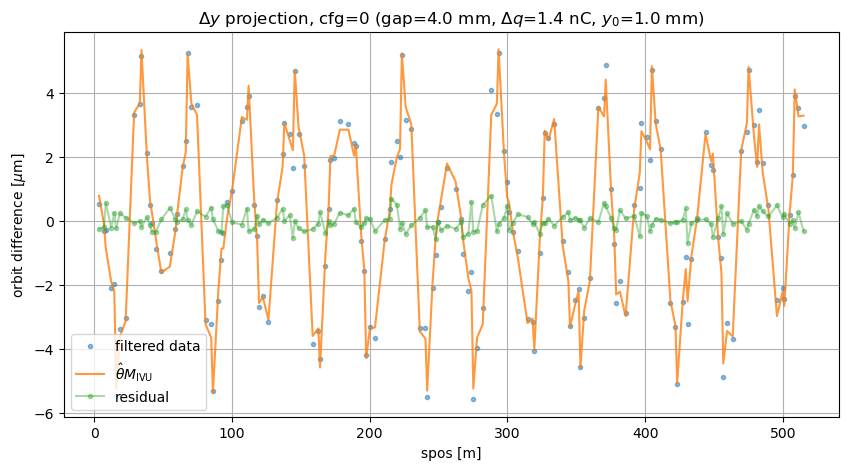

In [40]:
plot_theta_projection(
    cfg=0,
    delta_u_filt=delta_y_filt,
    theta_fit=theta_y_fit,
    plane="y",
)

### Plot projected kicks $\widehat{\theta}_{\rm cfg}^{u}$ vs $y_0$ before fit

After the projection, we have one fitted kick angle for each configuration:

\begin{equation}
\widehat{\theta}_{\rm cfg}^{u} \; = \; \widehat{\theta}^{u}(gap,\, \Delta q,\, y_0)
\end{equation}

Before extracting the kick factor, we can plot these values as a function of $y_0$ for different $gaps$ and $\Delta q$'s for visualization.

In [41]:
def plot_theta_values(theta_fit, gaps='all', plane="y", normalized=False):
    """Plot projected theta values versus y0.

    Args:
        theta_fit (dict): Projection fit result.
        gaps (list): IVU gaps [m]. If 'all', use all gaps.
        plane (str): Transverse plane.
        normalized (bool): Whether to plot theta/delta_q.

    """
    theta = theta_fit["theta"]  # [rad]

    y0 = config_table["y0"].to_numpy()  # [m]
    delta_q_meas = config_table["delta_charge"].to_numpy()  # [C]
    delta_q_group = config_table["delta_q_group"].to_numpy()  # []
    gap_values_data = config_table["gap"].to_numpy()  # [m]

    if gaps=='all':
        gaps = np.sort(np.unique(gap_values_data))
    elif isinstance(gaps, float):
        gaps = [gaps]

    fig, ax = plt.subplots(figsize=(8, 5))

    if normalized:
        ylabel = r"$\hat{\theta}/\Delta q_{\rm meas}$ [nrad/nC]"
        title_start = rf"$\hat{{\theta}}^{plane}/\Delta q_{{\rm meas}}$"
    else:
        ylabel = r"$\hat{\theta}$ [nrad]"
        title_start = rf"$\hat{{\theta}}^{plane}$"

    for gap in gaps:
        mask_gap = np.isclose(gap_values_data, gap, rtol=0, atol=1e-12)
        groups = np.sort(np.unique(delta_q_group[mask_gap]))

        for group in groups:
            mask = mask_gap & (delta_q_group == group)

            if len(y0[mask]) == 0:
                continue

            group_nC = group * delta_q_group_step_nC  # [nC]

            if normalized:
                y_plot = theta[mask] / delta_q_meas[mask]  # [rad/C]
            else:
                y_plot = 1e9 * theta[mask]  # [nrad]

            ax.plot(
                1e3 * y0[mask],
                y_plot,
                marker="o",
                linewidth=1,
                markersize=5,
                label=(
                    rf"$gap$ = {1e3*gap:.1f} mm | "
                    rf"$\Delta q_{{\rm group}}$ = {group_nC:.1f} nC"
                ),
            )

    ax.set_title(rf"{title_start} vs $y_0$")
    ax.set_xlabel(r"$y_0$ [mm]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

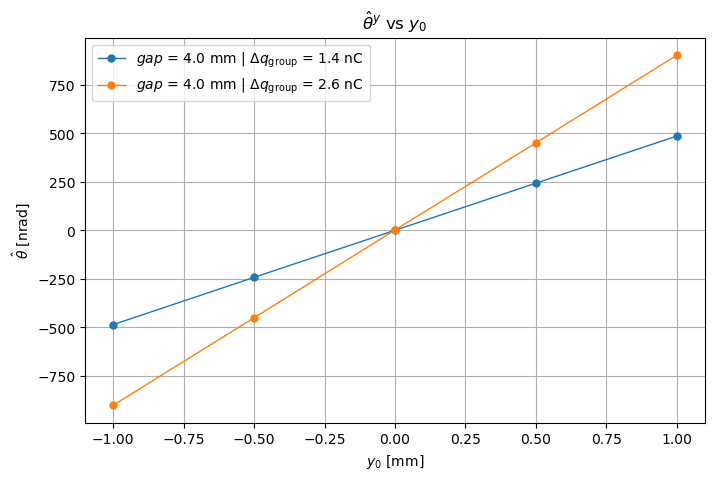

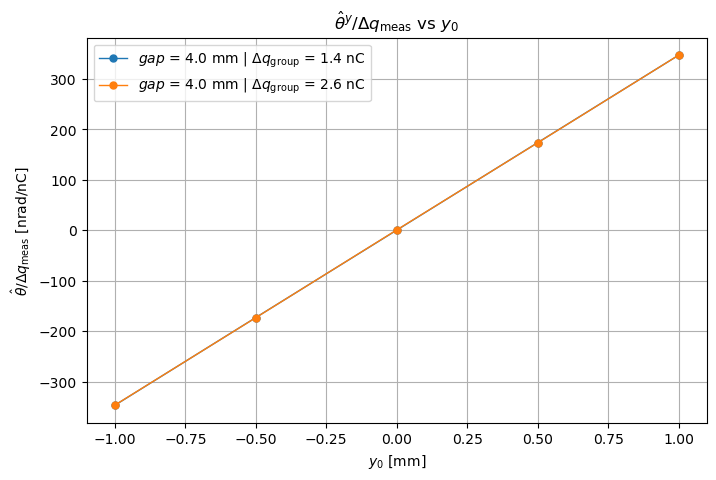

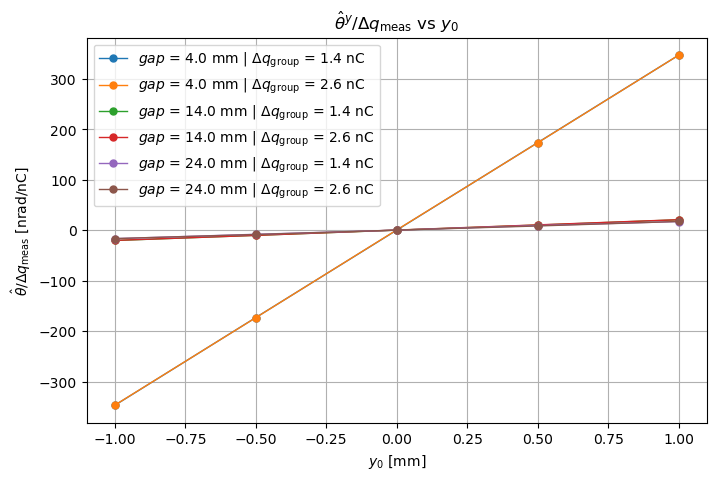

In [42]:
plot_theta_values(
    theta_fit=theta_y_fit,
    gaps=[4.0e-3],
    plane="y",
    normalized=False,
)

plot_theta_values(
    theta_fit=theta_y_fit,
    gaps=[4.0e-3],
    plane="y",normalized=True,
)

plot_theta_values(
    theta_fit=theta_y_fit,
    gaps='all',
    plane="y",
    normalized=True,
)

### Fit kick factor from $\widehat{\theta}$

For each configuration, we now have:

\begin{equation}
\widehat{\theta}_{\rm cfg}^{u}.
\end{equation}

For a fixed gap, we fit:

\begin{equation}
\frac{\widehat{\theta}_{\rm cfg}^{u}}{\Delta q_{\rm cfg}}
=
\mathrm{offset}(\Delta q_{\rm cfg})
+
a^u(g)y_{0,\rm cfg}.
\end{equation}

The slope is:

\begin{equation}
a^u(g)=\frac{k_\perp^u(g)}{E/e}.
\end{equation}

Select configurations

In [43]:
def get_delta_q_groups_from_nC(delta_q_groups_nC):
    """Convert charge-group values in nC to integer group labels.

    Args:
        delta_q_groups_nC (float or list): Charge groups [nC].

    Returns:
        delta_q_groups (numpy.ndarray): Integer charge groups.

    """
    if delta_q_groups_nC is None:
        return None

    if np.isscalar(delta_q_groups_nC):
        delta_q_groups_nC = [delta_q_groups_nC]

    delta_q_groups = np.array([
        int(np.round(delta_q_nC / delta_q_group_step_nC))
        for delta_q_nC in delta_q_groups_nC
    ])

    return delta_q_groups


def select_configs(gap, delta_q_groups_nC=None):
    """Select configurations for a given gap and, optionally, charge groups.

    Args:
        gap (float): IVU gap [m].
        delta_q_groups_nC (float or list): Charge groups [nC].

    Returns:
        cfg_idx (numpy.ndarray): Selected configuration indexes.

    """
    mask = np.isclose(config_table["gap"], gap, rtol=0, atol=1e-12)

    delta_q_groups = get_delta_q_groups_from_nC(delta_q_groups_nC)

    if delta_q_groups is not None:
        mask = mask & config_table["delta_q_group"].isin(delta_q_groups)

    cfg_idx = config_table.index[mask].to_numpy()

    return cfg_idx

In [44]:
# Example use
# cfg_idx = select_configs(
#     gap=4.0e-3,
#     delta_q_groups_nC=[2.6],
# )

# config_table.loc[cfg_idx]

Linear fit with one offset per $\Delta q$

In [45]:
def fit_theta_over_dq_vs_y0(y0, delta_q_meas, delta_q_group, theta):
    """Fit theta/delta_q_meas = offset(delta_q_group) + a*y0.

    Args:
        y0 (numpy.ndarray): Bump amplitudes [m].
        delta_q_meas (numpy.ndarray): Measured bunch charge differences [C].
        delta_q_group (numpy.ndarray): Integer charge groups.
        theta (numpy.ndarray): Projected kick angles [rad].

    Returns:
        fit (dict): Fit result.

    """
    theta_over_dq = theta / delta_q_meas  # [rad/C]

    groups = np.sort(np.unique(delta_q_group))
    n_groups = len(groups)

    # One offset per selected charge group + one common slope.
    X = np.zeros((len(theta_over_dq), n_groups + 1))  # []

    for i, group in enumerate(groups):
        mask = delta_q_group == group
        X[mask, i] = 1.0

    X[:, -1] = y0  # [m]

    coeffs, _, _, _ = np.linalg.lstsq(X, theta_over_dq, rcond=None)

    offsets = coeffs[:-1]  # [rad/C]
    a = coeffs[-1]  # [1/(C m)]

    theta_over_dq_fit = X @ coeffs  # [rad/C]
    residual = theta_over_dq - theta_over_dq_fit  # [rad/C]

    dof = len(theta_over_dq) - len(coeffs)  # []

    if dof > 0:
        residual_var = np.sum(residual**2) / dof  # [(rad/C)^2]
        cov = residual_var * np.linalg.pinv(X.T @ X)  # []
        coeffs_err = np.sqrt(np.diag(cov))  # []
    else:
        coeffs_err = np.full_like(coeffs, np.nan)  # []

    fit = {
        "theta_over_dq": theta_over_dq,
        "theta_over_dq_fit": theta_over_dq_fit,
        "residual": residual,
        "groups": groups,
        "offsets": offsets,
        "offsets_err": coeffs_err[:-1],
        "a": a,
        "a_err": coeffs_err[-1],
        "dof": dof,
    }

    return fit


def fit_kperp_from_theta(theta_fit, gap, delta_q_groups_nC=None, plane="y"):
    """Fit kick factor from projected theta values for one gap.

    Args:
        theta_fit (dict): Projection fit result.
        gap (float): IVU gap [m].
        delta_q_groups_nC (float or list): Charge groups to include [nC].
        plane (str): Transverse plane.

    Returns:
        kperp_fit (dict): Kick-factor fit result.

    """
    cfg_idx = select_configs(
        gap=gap,
        delta_q_groups_nC=delta_q_groups_nC,
    )

    if len(cfg_idx) == 0:
        raise ValueError("No configurations selected for this gap/charge group.")

    theta = theta_fit["theta"][cfg_idx]  # [rad]

    y0 = config_table.loc[cfg_idx, "y0"].to_numpy()  # [m]
    delta_q_meas = config_table.loc[cfg_idx, "delta_charge"].to_numpy()  # [C]
    delta_q_group = config_table.loc[cfg_idx, "delta_q_group"].to_numpy()  # []

    line_fit = fit_theta_over_dq_vs_y0(
        y0=y0,
        delta_q_meas=delta_q_meas,
        delta_q_group=delta_q_group,
        theta=theta,
    )

    a = line_fit["a"]  # [1/(C m)]
    a_err = line_fit["a_err"]  # [1/(C m)]

    kperp = beam_voltage * a  # [V/(C m)]
    kperp_err = beam_voltage * a_err  # [V/(C m)]

    kperp_fit = {
        "gap": gap,
        "plane": plane,
        "cfg_idx": cfg_idx,
        "theta": theta,
        "delta_q_meas": delta_q_meas,
        "delta_q_group": delta_q_group,
        "y0": y0,
        "theta_over_dq": line_fit["theta_over_dq"],
        "theta_over_dq_fit": line_fit["theta_over_dq_fit"],
        "groups": line_fit["groups"],
        "offsets": line_fit["offsets"],
        "offsets_err": line_fit["offsets_err"],
        "a": a,
        "a_err": a_err,
        "kperp": kperp,
        "kperp_err": kperp_err,
        "residual": line_fit["residual"],
        "dof": line_fit["dof"],
    }

    return kperp_fit

Ploting function (fit and exp. points)

In [46]:
def plot_theta_and_fit(kperp_fit, normalized=True):
    """Plot theta or theta/delta_q versus y0 with fitted lines.

    Args:
        kperp_fit (dict): Kick-factor fit result.
        normalized (bool): Whether to plot theta/delta_q.

    """
    gap = kperp_fit["gap"]  # [m]
    plane = kperp_fit["plane"]  # []

    y0 = kperp_fit["y0"]  # [m]
    theta = kperp_fit["theta"]  # [rad]
    delta_q_meas = kperp_fit["delta_q_meas"]  # [C]
    delta_q_group = kperp_fit["delta_q_group"]  # []

    a = kperp_fit["a"]  # [1/(C m)]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, group in enumerate(kperp_fit["groups"]):
        mask = delta_q_group == group
        group_nC = group * delta_q_group_step_nC  # [nC]

        if normalized:
            y_plot = theta[mask] / delta_q_meas[mask]  # [rad/C]

            y0_fit = np.linspace(
                np.min(y0[mask]),
                np.max(y0[mask]),
                100,
            )  # [m]

            y_fit = kperp_fit["offsets"][i] + a * y0_fit  # [rad/C]

            ax.plot(
                1e3 * y0[mask],
                y_plot,
                "o",
                label=rf"$\Delta q_{{\rm group}}$ = {group_nC:.1f} nC",
            )

            ax.plot(
                1e3 * y0_fit,
                y_fit,
                "-",
            )

            ylabel = r"$\hat{\theta}/\Delta q_{\rm meas}$ [nrad/nC]"
            title_start = rf"$\hat{{\theta}}^{plane}/\Delta q_{{\rm meas}}$"

        else:
            y_plot = 1e9 * theta[mask]  # [nrad]

            order = np.argsort(y0[mask])
            y0_sorted = y0[mask][order]  # [m]

            theta_fit_sorted = (
                delta_q_meas[mask][order]
                * kperp_fit["theta_over_dq_fit"][mask][order]
            )  # [rad]

            ax.plot(
                1e3 * y0[mask],
                y_plot,
                "o",
                label=rf"$\Delta q_{{\rm group}}$ = {group_nC:.1f} nC",
            )

            ax.plot(
                1e3 * y0_sorted,
                1e9 * theta_fit_sorted,
                "-",
            )

            ylabel = r"$\hat{\theta}$ [nrad]"
            title_start = rf"$\hat{{\theta}}^{plane}$"

    ax.set_title(
        rf"{title_start} vs $y_0$, "
        rf"gap = {1e3*gap:.1f} mm"
    )
    ax.set_xlabel(r"$y_0$ [mm]")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.show()

### Testing one gap !

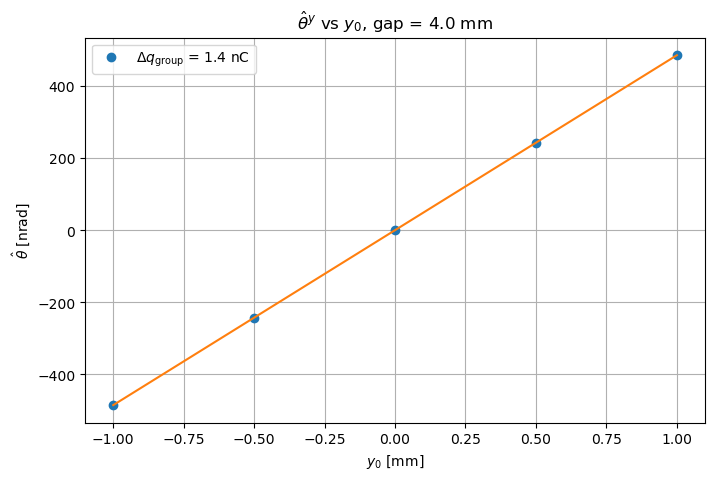

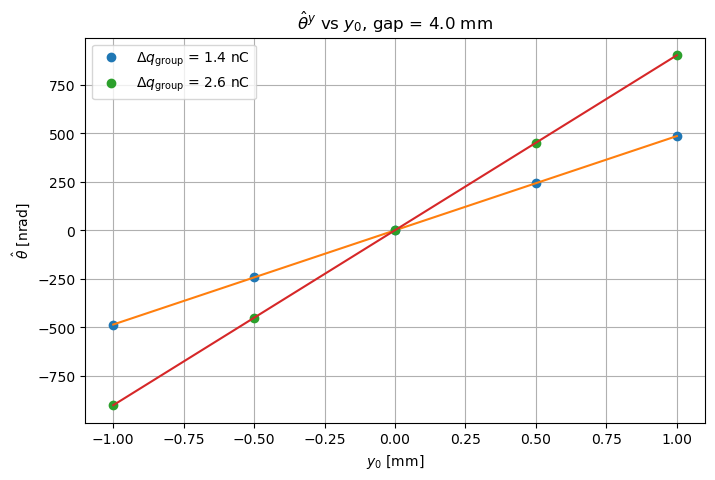

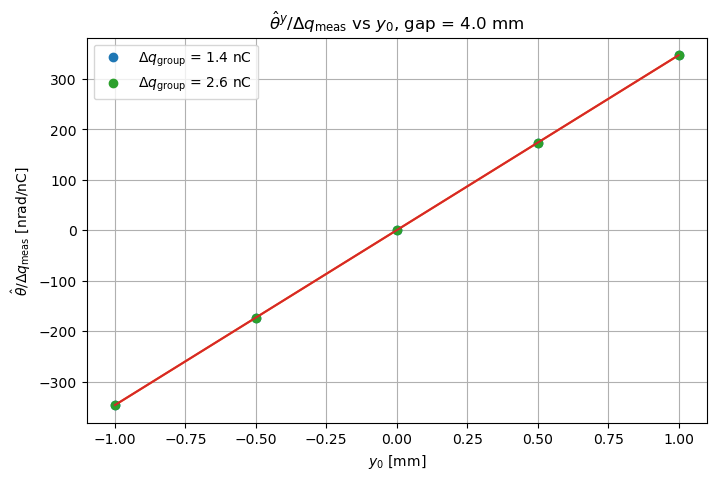

In [47]:
kperp_y_gap4_q14 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=4.0e-3,
    delta_q_groups_nC=[1.4],
    plane="y",
)

kperp_y_gap4 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=4.0e-3,
    delta_q_groups_nC=None, # None considers all groups
    plane="y",
)

plot_theta_and_fit(kperp_y_gap4_q14, normalized=False)

plot_theta_and_fit(kperp_y_gap4, normalized=False)
plot_theta_and_fit(kperp_y_gap4, normalized=True)


In [48]:
def print_kperp_summary(kperp_fit):
    """Print kick-factor fit summary.

    Args:
        kperp_fit (dict): Kick-factor fit result.

    """
    print("Kick-factor fit")
    print("---------------")
    print(f"plane     : {kperp_fit['plane']}")
    print(f"gap       : {1e3*kperp_fit['gap']:.1f} mm")
    print(f"n configs : {len(kperp_fit['cfg_idx'])}")
    print("")
    print(
        f"kperp     : {1e-12*kperp_fit['kperp']:.3f} +/- "
        f"{1e-12*kperp_fit['kperp_err']:.3f} [V/(pC m)]"
    )

In [49]:
print_kperp_summary(kperp_y_gap4)

Kick-factor fit
---------------
plane     : y
gap       : 4.0 mm
n configs : 10

kperp     : 1040.526 +/- 0.315 [V/(pC m)]


In [50]:
print_kperp_summary(kperp_y_gap4_q14)

Kick-factor fit
---------------
plane     : y
gap       : 4.0 mm
n configs : 5

kperp     : 1040.721 +/- 0.371 [V/(pC m)]


### Fit all gaps and join results

In [51]:
def make_kperp_results_table(kperp_fits, labels=None):
    """Create results table from selected kick-factor fits.

    Args:
        kperp_fits (list): List of kick-factor fit dictionaries.
        labels (list): Names for each fit.

    Returns:
        results_table (pandas.DataFrame): Results summary table.

    """
    if labels is None:
        labels = [f"fit_{i}" for i in range(len(kperp_fits))]

    rows = []

    for label, kperp_fit in zip(labels, kperp_fits):
        groups_nC = (
            delta_q_group_step_nC * kperp_fit["groups"]
        )  # [nC]

        groups_label = ", ".join([
            f"{group_nC:.1f}"
            for group_nC in groups_nC
        ])

        rows.append({
            "label": label,
            "gap": kperp_fit["gap"],
            "gap_mm": 1e3 * kperp_fit["gap"],
            "plane": kperp_fit["plane"],
            "delta_q_groups_nC": groups_label,
            "n_configs": len(kperp_fit["cfg_idx"]),
            "dof": kperp_fit["dof"],
            "a": kperp_fit["a"],
            "a_err": kperp_fit["a_err"],
            "kperp": kperp_fit["kperp"],
            "kperp_err": kperp_fit["kperp_err"],
            "kperp_v_per_pC_m": 1e-12 * kperp_fit["kperp"],
            "kperp_err_v_per_pC_m": 1e-12 * kperp_fit["kperp_err"],
        })

    results_table = pd.DataFrame(rows)

    return results_table

Calculate fits of configurations of interest

In [52]:
kperp_y_gap4 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=4.0e-3,
    delta_q_groups_nC=[1.4, 2.6],
    plane="y",
)

kperp_y_gap4_q26 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=4.0e-3,
    delta_q_groups_nC=[2.6],
    plane="y",
)

kperp_y_gap14 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=14.0e-3,
    delta_q_groups_nC=[1.4, 2.6],
    plane="y",
)

kperp_y_gap24 = fit_kperp_from_theta(
    theta_fit=theta_y_fit,
    gap=24.0e-3,
    delta_q_groups_nC=[1.4, 2.6],
    plane="y",
)

Join results

In [53]:
kperp_fits_y = [
    kperp_y_gap4,
    kperp_y_gap4_q26,
    kperp_y_gap14,
    kperp_y_gap24
]

results_table_y = make_kperp_results_table(
    kperp_fits=kperp_fits_y,
    labels=[
        "gap4",
        "gap4_q26",
        "gap14",
        "gap24"
    ],
)

Display results

In [54]:
results_table_y[[
    "label",
    "gap_mm",
    "kperp_v_per_pC_m",
    "kperp_err_v_per_pC_m",
    "delta_q_groups_nC",
    "n_configs"
]]

,label,gap_mm,kperp_v_per_pC_m,kperp_err_v_per_pC_m,delta_q_groups_nC,n_configs
0,gap4,4.0,1040.526157,0.314830,"1.4, 2.6",10
1,gap4_q26,4.0,1040.330896,0.547058,2.6,5
2,gap14,14.0,61.633917,0.144741,"1.4, 2.6",10
3,gap24,24.0,50.975481,0.311565,"1.4, 2.6",10


### Plot kick factor vs gap

In [55]:
def plot_kperp_vs_gap(fit_table, expected_table=None):
    """Plot kick factor as a function of IVU gap.

    Args:
        fit_table (pandas.DataFrame): Fit summary table.
        expected_table (pandas.DataFrame): Expected/simulated values.

    """
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(
        fit_table["gap_mm"],
        fit_table["kperp_v_per_pC_m"],
        yerr=fit_table["kperp_err_v_per_pC_m"],
        marker="o",
        capsize=4,
        linestyle="-",
        label="measurement fit",
    )

    if expected_table is not None:
        ax.plot(
            expected_table["gap_mm"],
            expected_table["kperp_v_per_pC_m"],
            "s--",
            label="expected/simulated",
        )

    ax.set_title(r"Transverse kick factor versus IVU gap")
    ax.set_xlabel("gap [mm]")
    ax.set_ylabel(r"$k_\perp$ [V/(pC m)]")
    ax.grid(True)
    ax.legend()
    plt.show()

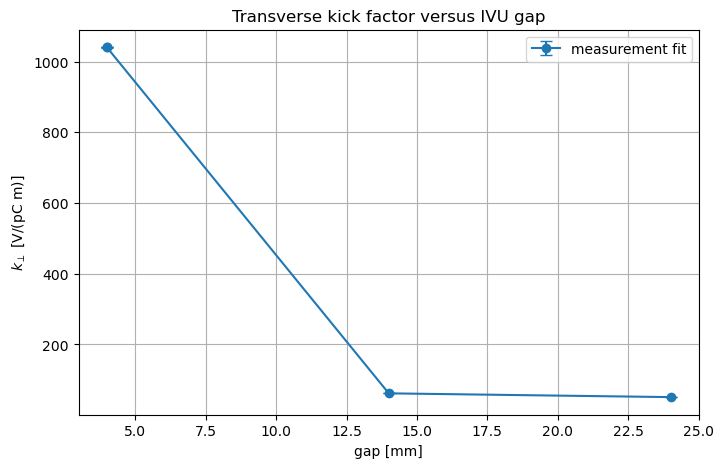

In [56]:
plot_kperp_vs_gap(results_table_y)

### Save processed fit results

In [57]:
processed_dir = os.path.join(os.path.dirname(data_dir), "processed")
os.makedirs(processed_dir, exist_ok=True)

results_table_y.to_csv(
    os.path.join(processed_dir, "fit_results_y.csv"),
    index=False,
)

with open(os.path.join(processed_dir, "fit_results_y.pickle"), "wb") as f:
    pickle.dump(
        {
            "config_table": config_table,
            "delta_y_proc": delta_y_proc,
            "delta_y_filt": delta_y_filt,
            "theta_y_fit": theta_y_fit,
            "fit_table_y": results_table_y,
            "kperp_fits_y": kperp_fits_y,
        },
        f,
    )

print("Saved processed fit results in:")
print(processed_dir)

Saved processed fit results in:
/home/henrique.silvestre/fac-henrique/coding/machine_studies/tests_and_synthetic_data/data/processed
